In [5]:
import pathlib

# define an output path
output_path = pathlib.Path("./output")
# Create the output path
output_path.mkdir(exist_ok=True)

# Define database path
database_path = output_path / "database.db"

In [6]:
import pycolmap

# Defined the image directory
image_dir = pathlib.Path("./data/01_nerf/01_lego_small")

# Extract Features
pycolmap.extract_features(database_path, image_dir, camera_model='OPENCV')

In [7]:
# Load the database
#db = pycolmap.Database(database_path)
#db.num_keypoints

In [8]:
import pycolmap
import numpy as np

# Open the database
db = pycolmap.Database(database_path)

# Get all images from the database
images = db.read_all_images()

# Check if there are any images
if images:
    # Get the first image id from the list of images
    first_image_id = images[0].image_id
    
    # Get the image object
    first_image = images[0]
    
    # Get the keypoints for the first image
    keypoints = db.read_keypoints(first_image_id)
    
    print(f"Features for image: {first_image.name}")
    print(f"Number of keypoints: {len(keypoints)}")
    
    # Print the first 5 keypoints
    print("First 5 keypoints (x, y, scale, orientation):")
    for i in range(min(5, len(keypoints))):
        kp = keypoints[i]
        print(f"  {i+1}: (x={kp[0]:.2f}, y={kp[1]:.2f}, scale={kp[2]:.2f}, orientation={kp[3]:.2f})")
else:
    print("No images found in the database.")

Features for image: r_10.png
Number of keypoints: 3372
First 5 keypoints (x, y, scale, orientation):
  1: (x=556.74, y=113.09, scale=-0.05, orientation=-1.06)
  2: (x=593.48, y=118.40, scale=-0.33, orientation=0.93)
  3: (x=593.48, y=118.40, scale=0.66, orientation=0.74)
  4: (x=584.52, y=121.27, scale=-0.09, orientation=0.82)
  5: (x=525.89, y=123.06, scale=-0.41, orientation=-0.98)


In [9]:
# Get the descriptors for the first image
descriptors = db.read_descriptors(first_image_id)

print(f"Shape of descriptors array: {descriptors.shape}")

# Print the first 2 descriptors
print("First 2 descriptors:")
for i in range(min(2, len(descriptors))):
    desc = descriptors[i]
    print(f"  {i+1}: {desc}")

Shape of descriptors array: (3372, 128)
First 2 descriptors:
  1: [ 69  10   0   0   0   0   0  15 144  27   0   4  11   0   0  31  99  14
   0  21  80   1   0   9   0   1   3  22 105  11   1   0  77  18   0   0
   0   0   0  14 144  53   3   3  12   0   0  29 110  27   5  16  90   2
   0   7   2   3   0  19 117  13   3   1  77  11   0   0   0   0   0  40
 144  38   3   5  11   4   2 102 102  22   6  20  89   7   3  41   3   4
   2  23 117   2   0   0  93  23   0   0   0   0   0  28 144  34   0   2
  19   5   3  82  66   6   0  10  87  10   4  36   1   1   1  16 105  13
   2   1]
  2: [  8   3   0   0  11  79  34  17  91  18   0   0   5  34  36  74  99  25
   3   7   4   0   0  63  39   3   3  61  74   1   3  39   2   9   5   5
  28  87  39  13  70  35   0   0  10  34  47  55 106  53  22  47  21   0
  14  44  35  13  20 106  85   0   1  16  28  41  36  25  42  46  27  42
  33   6   3   8  21  27  87 102  52  14  17 106  87  27  58  69  12   6
  13 106  93   0   2   3  63  36  24   9   

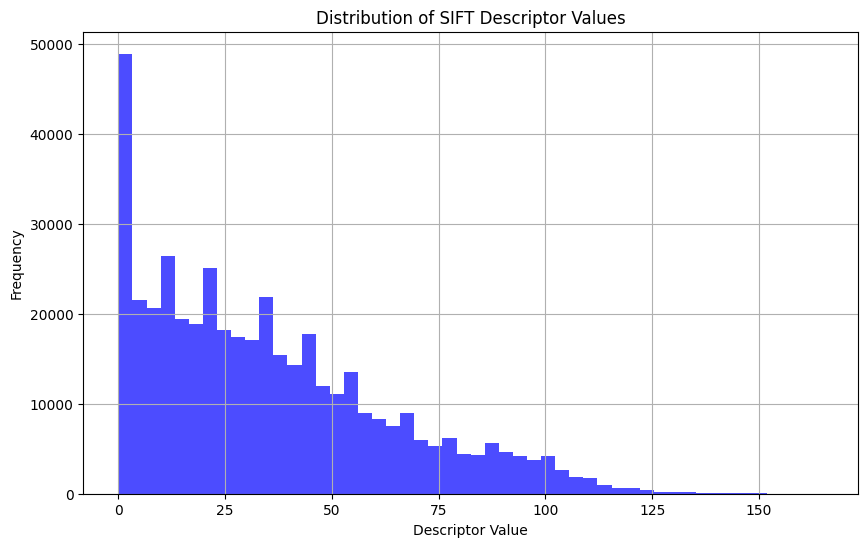

In [10]:
import matplotlib.pyplot as plt

# Flatten the descriptors array to get a 1D array of all descriptor values
descriptor_values = descriptors.flatten()

# Plot a histogram of the descriptor values
plt.figure(figsize=(10, 6))
plt.hist(descriptor_values, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of SIFT Descriptor Values')
plt.xlabel('Descriptor Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

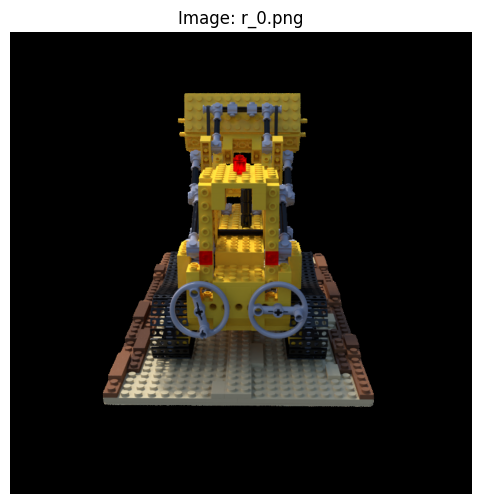

In [12]:
import matplotlib.pyplot as plt
import cv2
import pathlib

# Get the image directory and list images
image_dir = pathlib.Path("./data/01_nerf/01_lego_small")
image_files = sorted(image_dir.glob("*.png"))

if image_files:
    # Load the first image
    img_path = image_files[0]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(f"Image: {img_path.name}")
    plt.axis('off')
    plt.show()
else:
    print("No images found in input/01_lego_small directory.")

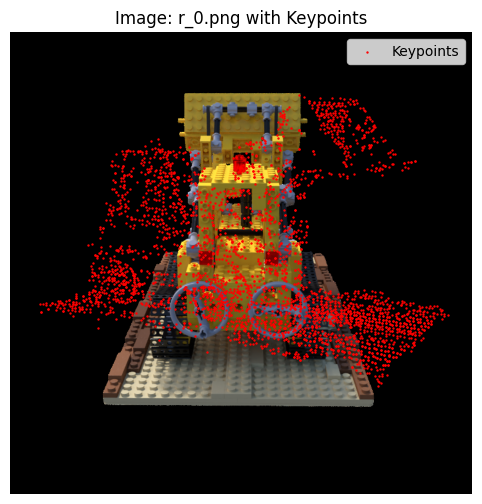

In [15]:
import matplotlib.pyplot as plt
import cv2
import pathlib

# Get the image directory and list images
image_dir = pathlib.Path("./data/01_nerf/01_lego_small")
image_files = sorted(image_dir.glob("*.png"))

if image_files:
    # Load the first image
    img_path = image_files[0]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Overlay keypoints
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.scatter(keypoints[:, 0], keypoints[:, 1], s=0.5, c='red', marker='o', label='Keypoints')
    plt.title(f"Image: {img_path.name} with Keypoints")
    plt.axis('off')
    plt.legend()
    plt.show()
else:
    print("No images found in input/01_lego_small directory.")

In [16]:
# Feature Matching
pycolmap.match_exhaustive(database_path)

In [17]:
# Read the matches from the database
pair_ids, all_matches = db.read_all_matches()

print(f"Number of image pairs with matches: {len(pair_ids)}")

# Print some matches for the first pair
if pair_ids:
    # Get the first pair_id
    first_pair_id = pair_ids[0]
    
    # Convert pair_id to image_ids
    image_id1, image_id2 = pycolmap.Database.pair_id_to_image_pair(first_pair_id)
    
    # Get the matches for this pair
    image_pair_matches = all_matches[0]
    
    # Get the images
    images = db.read_all_images()
    image_map = {im.image_id: im for im in images}
    
    # Check if image_id1 and image_id2 are in image_map
    if image_id1 in image_map and image_id2 in image_map:
        print(f"\nMatches between image {image_map[image_id1].name} and image {image_map[image_id2].name}:")
        print(f"Number of matches: {len(image_pair_matches)}")
        
        # Print the first 5 matches
        print("First 5 matches (keypoint_index1, keypoint_index2):")
        for i in range(min(5, len(image_pair_matches))):
            kp_idx1, kp_idx2 = image_pair_matches[i]
            print(f"  {i+1}: ({kp_idx1}, {kp_idx2})")
    else:
        print("Could not find image names for the matched pair.")

Number of image pairs with matches: 424

Matches between image r_10.png and image r_17.png:
Number of matches: 26
First 5 matches (keypoint_index1, keypoint_index2):
  1: (51, 25)
  2: (143, 1096)
  3: (430, 1390)
  4: (431, 1391)
  5: (454, 701)


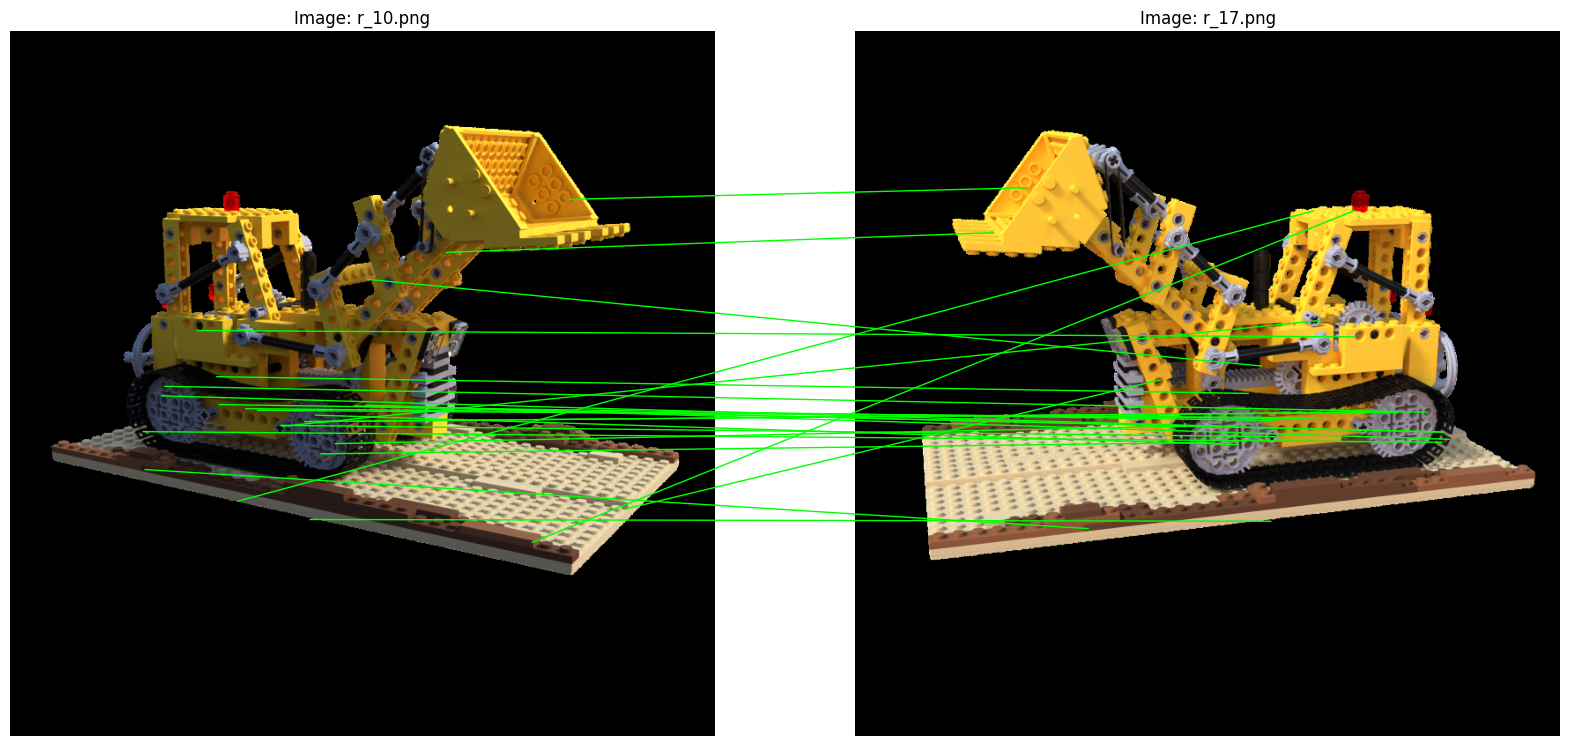

In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import ConnectionPatch

# This code reuses variables from the previous cell:
# pair_ids, all_matches, db, image_dir

if pair_ids:
    # Get the first pair of matched images
    first_pair_id = pair_ids[0]
    image_id1, image_id2 = pycolmap.Database.pair_id_to_image_pair(first_pair_id)
    
    # Get the matches for this pair
    image_pair_matches = all_matches[0]
    
    # Get image names and paths
    images = db.read_all_images()
    image_map = {im.image_id: im for im in images}
    
    if image_id1 in image_map and image_id2 in image_map:
        img_name1 = image_map[image_id1].name
        img_name2 = image_map[image_id2].name
        
        img_path1 = image_dir / img_name1
        img_path2 = image_dir / img_name2
        
        # Load images
        img1 = cv2.imread(str(img_path1))
        img2 = cv2.imread(str(img_path2))
        img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
        img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
        
        # Get keypoints
        keypoints1 = db.read_keypoints(image_id1)
        keypoints2 = db.read_keypoints(image_id2)
        
        # Create a figure with two subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        
        # Display images
        ax1.imshow(img1_rgb)
        ax1.set_title(f"Image: {img_name1}")
        ax1.axis('off')
        
        ax2.imshow(img2_rgb)
        ax2.set_title(f"Image: {img_name2}")
        ax2.axis('off')
        
        # Draw lines for the first 50 matches
        for i in range(min(50, len(image_pair_matches))):
            kp_idx1, kp_idx2 = image_pair_matches[i]
            
            # Get keypoint coordinates
            pt1 = keypoints1[kp_idx1][:2]
            pt2 = keypoints2[kp_idx2][:2]
            
            # Create a connection patch
            con = ConnectionPatch(xyA=pt2, xyB=pt1, coordsA=ax2.transData, coordsB=ax1.transData,
                                  color=(0,1,0), linewidth=1)
            fig.add_artist(con)

        plt.show()
    else:
        print("Could not find image names for the matched pair.")
else:
    print("No matches found in the database.")

In [ ]:
maps = pycolmap.incremental_mapping(database_path, image_dir, output_path)

In [28]:
maps

{0: Reconstruction(num_rigs=5, num_cameras=5, num_frames=5, num_reg_frames=5, num_images=5, num_points3D=1068),
 1: Reconstruction(num_rigs=37, num_cameras=37, num_frames=37, num_reg_frames=37, num_images=37, num_points3D=4029),
 2: Reconstruction(num_rigs=11, num_cameras=11, num_frames=11, num_reg_frames=11, num_images=11, num_points3D=679),
 3: Reconstruction(num_rigs=10, num_cameras=10, num_frames=10, num_reg_frames=10, num_images=10, num_points3D=793)}

In [36]:
maps[0].points3D

Point3DMap{1: Point3D(xyz=[1.48485, -1.20778, 14.7349], track_len=3), 944: Point3D(xyz=[-0.543535, -0.908897, 14.488], track_len=2), 393: Point3D(xyz=[2.38464, 2.12511, 15.5017], track_len=4), 1054: Point3D(xyz=[1.97813, 1.24005, 15.8939], track_len=2), 2: Point3D(xyz=[0.826789, 0.225359, 10.0067], track_len=2), 3: Point3D(xyz=[1.56346, 1.26184, 15.8154], track_len=2), 1064: Point3D(xyz=[2.29458, 1.4233, 16.1133], track_len=3), 387: Point3D(xyz=[4.26195, 1.64859, 15.6443], track_len=4), 4: Point3D(xyz=[2.03368, 1.75501, 16.278], track_len=3), 5: Point3D(xyz=[-1.05794, 2.08705, 15.4898], track_len=4), 1066: Point3D(xyz=[2.7933, 1.4922, 16.0692], track_len=2), 397: Point3D(xyz=[2.38887, 2.29093, 15.4502], track_len=4), 6: Point3D(xyz=[0.340414, 2.84655, 15.0765], track_len=3), 7: Point3D(xyz=[0.340414, 2.84655, 15.0765], track_len=3), 8: Point3D(xyz=[0.699873, -0.740428, 15.7148], track_len=5), 9: Point3D(xyz=[-0.895537, -0.460438, 15.9993], track_len=2), 952: Point3D(xyz=[1.9758, 0.9606